This notebook reproduces the simulation and application results from the paper.

Some sections use PyTorch for GPU acceleration. If a GPU is not available, search for `gpu=True` in the notebook and replace it with `gpu=False`.

In [1]:
# Import modules
import os
import numpy as np
try:
    import torch
except ImportError:
    torch = None
import gc
import sys
from network import *
from GNAR import *
from TVGNAR import *
import matplotlib.pyplot as plt
import time
from tqdm import tqdm
import json
from copy import deepcopy

# Vts and networks used for NY COVID application
edges = np.genfromtxt("Network.csv",delimiter=",")[1:,1:]
edges = {key: (edges[key,:][~np.isnan(edges[key,])]-1).astype(int).tolist() for key in range(edges.shape[0])}

network_NY = Network(edges,symmetry=True)
vts = np.genfromtxt("vts.csv",delimiter=",")[1:,1:]
vts = vts[~np.isnan(vts).any(axis=1), :]
vts_log = np.log(vts+1)

# Vts and networks used for NHS Ventilation bed application
with open('CovidEdges.json') as f:
    d = json.load(f)
    covid_edges = {key: [x-1 for x in d[key]] for key in range(len(d))}

with open('CovidDists.json') as f:
    d = json.load(f)
    covid_dists = {key: np.array(d[key]) for key in range(len(d))}

covid_vts = np.exp(np.genfromtxt("CovidVTS.csv",skip_header=1))-1
covid_vts_log = np.genfromtxt("CovidVTS.csv",skip_header=1)
covid_network = Network(covid_edges,covid_dists)
covid_network_0 = Network(covid_edges,covid_dists,gamma=0)

# Forecasting Simulation

In [2]:
# Used for faster threading for VARLasso if set gpu to false, adjust this based on machine
os.environ.setdefault("OMP_NUM_THREADS", "1")
os.environ.setdefault("MKL_NUM_THREADS", "1")
os.environ.setdefault("OPENBLAS_NUM_THREADS", "1")
os.environ.setdefault("VECLIB_MAXIMUM_THREADS", "1")
os.environ.setdefault("NUMEXPR_NUM_THREADS", "1")

'1'

In [2]:
def forecast_sim(coefs, alpha_order, beta_order, family, T,b):
    """
    Runs the simulation in the main document.
    Prints (in order):
    Average sum of predictive squared error of
        Hard thresholding
        Soft thresholding
        No thresholding
        Hard thresholding with refit
        Soft thresholding with refit
    Average sum of squared error of estimated coefficients of
        Hard thresholding
        Soft thresholding
        No thresholding
        Hard thresholding with refit
        Soft thresholding with refit
    """
    random.seed(1)
    network = tridiagonal_network(32)
    spse_tv_h=[]
    spse_tv_s = []
    spse_tv_n=[]
    spse_tv_h_r=[]
    spse_tv_s_r=[]
    sse_tv_h_coef=[]
    sse_tv_s_coef = []
    sse_tv_n_coef=[]
    sse_tv_h_r_coef=[]
    sse_tv_s_r_coef=[]
    for _ in tqdm(range(100)):
        
        np.random.seed(_)
        vts_sim = TVGNAR_sim(network, alpha_order, beta_order, coefs, intercept=True, global_intercept=True, error_cov_mat=0.1*np.identity(network.size),length=T+1,burn_in=b)
        
        g_tv_s_r = TVGNAR(alpha_order,beta_order,intercept=False,global_intercept=False,family=family,gpu=True,basis_order=7,boundary_mode="reflect",boundary_pad=None)
        g_tv_s_r.fit(network,vts_sim[:-1],thresh="soft",tau="auto",refit=True,refit_endpoint_only=True)
        spse_tv_s_r.append( np.sum((vts_sim[-1:]-g_tv_s_r.predict(1))**2) )
        sse_tv_s_r_coef.append( np.sum((coefs[-1,:-1]-g_tv_s_r.last_coefs)**2) )
    
        g_tv_h_r = TVGNAR(alpha_order,beta_order,intercept=False,global_intercept=False,family=family,gpu=True,basis_order=7,boundary_mode="reflect",boundary_pad=None)
        g_tv_h_r.fit(network,vts_sim[:-1],thresh="hard",tau="auto",refit=True,refit_endpoint_only=True)
        spse_tv_h_r.append( np.sum((vts_sim[-1:]-g_tv_h_r.predict(1))**2) )
        sse_tv_h_r_coef.append( np.sum((coefs[-1,:-1]-g_tv_h_r.last_coefs)**2) )
    
        g_tv_n = TVGNAR(alpha_order,beta_order,intercept=False,global_intercept=False,family=family,gpu=True,basis_order=7,boundary_mode="reflect",boundary_pad=None)
        g_tv_n.fit(network,vts_sim[:-1],thresh=None)
        spse_tv_n.append( np.sum((vts_sim[-1:]-g_tv_n.predict(1))**2) )
        sse_tv_n_coef.append( np.sum((coefs[-1,:-1]-g_tv_n.last_coefs)**2) )
    
        g_tv_h = TVGNAR(alpha_order,beta_order,intercept=False,global_intercept=False,family=family,gpu=True,basis_order=7,boundary_mode="reflect",boundary_pad=None)
        g_tv_h.fit(network,vts_sim[:-1],thresh="hard",tau="auto")
        spse_tv_h.append( np.sum((vts_sim[-1:]-g_tv_h.predict(1))**2) )
        sse_tv_h_coef.append( np.sum((coefs[-1,:-1]-g_tv_h.last_coefs)**2) )
    
        g_tv_s = TVGNAR(alpha_order,beta_order,intercept=False,global_intercept=False,family=family,gpu=True,basis_order=7,boundary_mode="reflect",boundary_pad=None)
        g_tv_s.fit(network,vts_sim[:-1],thresh="soft",tau="auto")
        spse_tv_s.append( np.sum((vts_sim[-1:]-g_tv_s.predict(1))**2) )
        sse_tv_s_coef.append( np.sum((coefs[-1,:-1]-g_tv_s.last_coefs)**2) )
    print(np.mean(spse_tv_n))
    print(np.mean(spse_tv_h))
    print(np.mean(spse_tv_s))
    print(np.mean(spse_tv_h_r))
    print(np.mean(spse_tv_s_r))
    print(np.mean(sse_tv_n_coef))
    print(np.mean(sse_tv_h_coef))
    print(np.mean(sse_tv_s_coef))
    print(np.mean(sse_tv_h_r_coef))
    print(np.mean(sse_tv_s_r_coef))

In [5]:
def forecast_sim_vl(coefs, p, T,b,vl_param):
    """
    Runs the simulation in the main document.
    Prints (in order):
    Average sum of predictive squared error of
        GNAR
        VAR
        VARLasso
        AR
    """
    random.seed(1)
    network = tridiagonal_network(32)
    spse_g = []
    spse_v=[]
    spse_vl = []
    spse_ar = []
    for _ in tqdm(range(100)):
        np.random.seed(_)
        vts_sim = TVGNAR_sim(network, p, [1 for _ in range(p)], coefs, intercept=True, global_intercept=True, error_cov_mat=0.1*np.identity(network.size),length=T+1,burn_in=b)
        g = GNAR(p,[1 for _ in range(p)],intercept=False,global_intercept=True)
        g.fit(network,vts_sim[:-1])
        spse_g.append( np.sum((vts_sim[-1:]-g.predict(1))**2) )
        
        v = VARLasso(p,0)
        v.fit(vts_sim[:-1])
        spse_v.append( np.sum((vts_sim[-1:]-v.predict(vts_sim[-1-p:-1]))**2) )
    
        vl = VARLasso(p,vl_param,gpu=True)
        vl.fit(vts_sim[:-1])
        spse_vl.append( np.sum((vts_sim[-1:]-vl.predict(vts_sim[-1-p:-1]))**2) )
        
        ar = GNAR(p,[0 for _ in range(p)],intercept=False,global_intercept=True,global_alpha=False)
        ar.fit(network,vts_sim[:-1])
        spse_ar.append( np.sum((vts_sim[-1:]-ar.predict(1))**2) )
        
    print(np.mean(spse_g))
    print(np.mean(spse_v))
    print(np.mean(spse_vl))
    print(np.mean(spse_ar))

#### case 1

In [49]:
T=1000
b=10
def alpha_fun(t):
        return np.ones_like(t)*0.55
    
def beta_fun(t):
    return np.ones_like(t)*0.35
    
def const_fun(t):
    return np.zeros_like(t)

coefs = np.zeros((T+b+1,3))
coefs[:,0] = alpha_fun(np.arange(-b,T+1))
coefs[:,1] = beta_fun(np.arange(-b,T+1))
coefs[:,2] = const_fun(np.arange(-b,T+1))
forecast_sim(coefs,1,[1],"db4",T,b)

100%|████████████████████████████████████████████████████████████████████████████████| 100/100 [02:26<00:00,  1.47s/it]


3.4307818817473787
3.223283305819956
3.2230717111544633
3.2229414039210296
3.2229211724707225
0.04762297235431467
0.0007804941608786159
0.0006267680476162424
0.0005139969957883957
0.0005135046434842302


In [50]:
forecast_sim(coefs,1,[1],"haar",T,b)

100%|████████████████████████████████████████████████████████████████████████████████| 100/100 [02:15<00:00,  1.36s/it]


3.278141111313643
3.2209938853147237
3.2209938853147237
3.2201881554159804
3.2201807389326627
0.014501926467781291
0.0001510315172017146
0.0001510315172017146
4.4417918812726354e-05
4.476938590148232e-05


In [51]:
forecast_sim_vl(coefs,1,T,b,7e-3)

100%|████████████████████████████████████████████████████████████████████████████████| 100/100 [00:23<00:00,  4.26it/s]

3.2201807001164537
3.358932101980487
3.267441182671845
3.647597424794564


#### case 2

In [52]:
T = 1000
b=10

def alpha_fun(t):
    return np.cos(t/(T)*2*np.pi)**2/2

def beta_fun(t):
    return np.sin(t/(T)*2*np.pi)**(3)*0.5
    
def const_fun(t):
    return np.zeros_like(t)

coefs = np.zeros((T+b+1,3))
coefs[:,0] = alpha_fun(np.arange(-b,T+1))
coefs[:,1] = beta_fun(np.arange(-b,T+1))
coefs[:,2] = const_fun(np.arange(-b,T+1))
forecast_sim(coefs,1,[1],"db4",T,b)

100%|████████████████████████████████████████████████████████████████████████████████| 100/100 [02:24<00:00,  1.44s/it]


3.390087804727305
3.225797980667398
3.225911719432379
3.2257768931067123
3.225783294483545
0.04415252135675947
0.0022412192413329094
0.0020022729379596243
0.0018306900995267155
0.001830733844429327


In [17]:
T = 1000
b=10

def alpha_fun(t):
    return np.cos(t/(T)*2*np.pi)**2/2

def beta_fun(t):
    return np.sin(t/(T)*2*np.pi)**(3)*0.5
    
def const_fun(t):
    return np.zeros_like(t)

coefs = np.zeros((T+b+1,3))
coefs[:,0] = alpha_fun(np.arange(-b,T+1))
coefs[:,1] = beta_fun(np.arange(-b,T+1))
coefs[:,2] = const_fun(np.arange(-b,T+1))
forecast_sim(coefs,1,[1],"db4",T,b)

100%|████████████████████████████████████████████████████████████████████████████████| 100/100 [02:33<00:00,  1.53s/it]


3.390087804727305
3.225797980667398
3.225911719432379
3.2257768931067123
3.225783294483545
0.04415252135675947
0.0022412192413329094
0.0020022729379596243
0.0018306900995267155
0.001830733844429327


In [53]:
forecast_sim(coefs,1,[1],"haar",T,b)

100%|████████████████████████████████████████████████████████████████████████████████| 100/100 [02:16<00:00,  1.36s/it]


3.25877194038325
3.2346252459930365
3.302851941868588
3.2307978423990766
3.2297418830001705
0.018240614019401007
0.007284979704114112
0.024254076756116287
0.005866434237325956
0.005575437487241128


In [59]:
forecast_sim_vl(coefs,1,T,b,2e-3)

100%|████████████████████████████████████████████████████████████████████████████████| 100/100 [00:25<00:00,  3.98it/s]

3.426578835831728
3.540421041931719
3.510644355584569
3.4325602295460396


#### case 3

In [83]:
T = 1000
b=10
def alpha_fun(t):
    x = np.asarray(t, dtype=float) / T

    return np.where(
        x <= 0,
        0.5,
        np.where(
            x <= 0.5,
            0.5 - 2*x,  # 0.5 at x=0 down to -0.5 at x=0.5
            2*x - 1.5    # -0.5 at x=0.5 up to 0.5 at x=1
        )
    )

def beta_fun(t):
    x = np.asarray(t, dtype=float) / T

    return np.where(
        x <= 0,
        0.45,
        np.where(
            x <= 0.5,
            0.45 - 1.8*x,   #  0.45 at x=0 down to -0.45 at x=0.5
            1.8*x - 1.35   # -0.45 at x=0.5 up to 0.45 at x=1
        )
    )
    
def const_fun(t):
    return np.zeros_like(t)

coefs = np.zeros((T+b+1,3))
coefs[:,0] = alpha_fun(np.arange(-b,T+1))
coefs[:,1] = beta_fun(np.arange(-b,T+1))
coefs[:,2] = const_fun(np.arange(-b,T+1))

In [62]:
forecast_sim(coefs,1,[1],"db4",T,b)

100%|████████████████████████████████████████████████████████████████████████████████| 100/100 [02:35<00:00,  1.55s/it]


3.4533050151343487
3.3038747826977573
3.3080409578040544
3.2624066276204444
3.2624061840463026
0.06083824029534018
0.008715111102193446
0.008995068622967752
0.004549782892197101
0.004548395518972743


In [63]:
forecast_sim(coefs,1,[1],"haar",T,b)

100%|████████████████████████████████████████████████████████████████████████████████| 100/100 [02:26<00:00,  1.46s/it]


3.2793448889825645
3.4069486660501838
4.0274385572134355
3.3293119277416316
3.3166017486665957
0.015102970653237775
0.020520154788299
0.08287524451192212
0.012863939474461385
0.011531737581292154


In [69]:
forecast_sim_vl(coefs,1,T,b,2e-4)

100%|████████████████████████████████████████████████████████████████████████████████| 100/100 [00:24<00:00,  4.14it/s]

7.717336668534471
7.018129989950815
7.0173661899121225
7.607604126686319


#### case 4

In [71]:
T = 1000
b=10

def alpha_fun(t):
    x = np.clip(np.asarray(t, dtype=float) / T, 0, 1)
    return 4 * (x - 0.5)**2 - 0.5
    # = 0.5 at x=0 and x=1, and -0.5 at x=0.5


def beta_fun(t):
    x = np.clip(np.asarray(t, dtype=float) / T, 0, 1)
    return (x - 0.5)**2

    
def const_fun(t):
    return np.zeros_like(t)

coefs = np.zeros((T+b+1,3))
coefs[:,0] = alpha_fun(np.arange(-b,T+1))
coefs[:,1] = beta_fun(np.arange(-b,T+1))
coefs[:,2] = const_fun(np.arange(-b,T+1))

In [72]:
forecast_sim(coefs,1,[1],"db4",T,b)
forecast_sim(coefs,1,[1],"haar",T,b)

100%|████████████████████████████████████████████████████████████████████████████████| 100/100 [02:37<00:00,  1.57s/it]


3.423870874657427
3.257362033577703
3.285776163114438
3.2435922882363455
3.243587647888406
0.052099417529881474
0.009935970657862246
0.015232315382496236
0.007054077301683452
0.007053291784490989


100%|████████████████████████████████████████████████████████████████████████████████| 100/100 [02:26<00:00,  1.47s/it]


3.269513868616828
3.3388091064121954
3.6744970367773493
3.310832254153146
3.3090372028484563
0.018526646625028568
0.024991164711195578
0.09545928538281054
0.019284962780941
0.018887017341402322


In [78]:
forecast_sim_vl(coefs,1,T,b,1e-1)

100%|████████████████████████████████████████████████████████████████████████████████| 100/100 [00:21<00:00,  4.62it/s]

5.532287563237211
5.419723750863841
4.731548080422414
5.736908417295785


#### case 5

In [4]:
T = 1000
b=10
def alpha_fun(t):
    x = np.asarray(t, dtype=float) / T

    return np.where(
        x <= 0,
        0.5,
        np.where(
            x <= 0.5,
            0.5 - 2*x,  # 0.5 at x=0 down to -0.5 at x=0.5
            2*x - 1.5   # -0.5 at x=0.5 up to 0.5 at x=1
        )
    )

def beta_fun(t):
    x = np.asarray(t, dtype=float) / T

    return np.where(
        x <= 0,
        0.45,
        np.where(
            x <= 0.5,
            0.45 - 1.8*x,   # 0.45 at x=0 down to -0.45 at x=0.5
            1.8*x - 1.35    # -0.45 at x=0.5 up to 0.45 at x=1
        )
    )

    
def const_fun(t):
    return np.zeros_like(t)

coefs = np.zeros((T+b+1,5))
coefs[:,0] = alpha_fun(np.arange(-b,T+1))*0.6
coefs[:,1] = beta_fun(np.arange(-b,T+1))*0.6
coefs[:,2] = alpha_fun(np.arange(-b,T+1))*0.4
coefs[:,3] = beta_fun(np.arange(-b,T+1))*0.4
coefs[:,4] = const_fun(np.arange(-b,T+1))

In [88]:
forecast_sim(coefs,2,[1,1],"db4",T,b)
forecast_sim(coefs,2,[1,1],"haar",T,b)

100%|████████████████████████████████████████████████████████████████████████████████| 100/100 [04:38<00:00,  2.78s/it]


3.5719583455667334
3.3271757552150625
3.326617900053945
3.291034374839328
3.290976183317732
0.12069261768508928
0.0059602271601561065
0.005939860080425442
0.003319689212100566
0.0033186456026461555


100%|████████████████████████████████████████████████████████████████████████████████| 100/100 [04:30<00:00,  2.71s/it]


3.3683876520691025
3.582439682344173
4.392687918949457
3.4159710195521935
3.383289278304364
0.04682365563750004
0.026758156183893985
0.08585587218738323
0.015569438209835059
0.012751415724678148


In [101]:
forecast_sim_vl(coefs,2,T,b,1e-5)

100%|████████████████████████████████████████████████████████████████████████████████| 100/100 [00:27<00:00,  3.65it/s]

4.836908683674029
4.745911616533976
4.7459681751676115
5.3731162494660225


# Application on NY COVID

## Fitting a TV-GNAR(1,[1]) model

In [8]:
g_tv = TVGNAR(1,[1],intercept=False,family='db8') # Use DB8 wavelets and universal soft thresholding.
g_tv.fit(network_NY,vts_log,thresh="soft",ind_thresh=False)

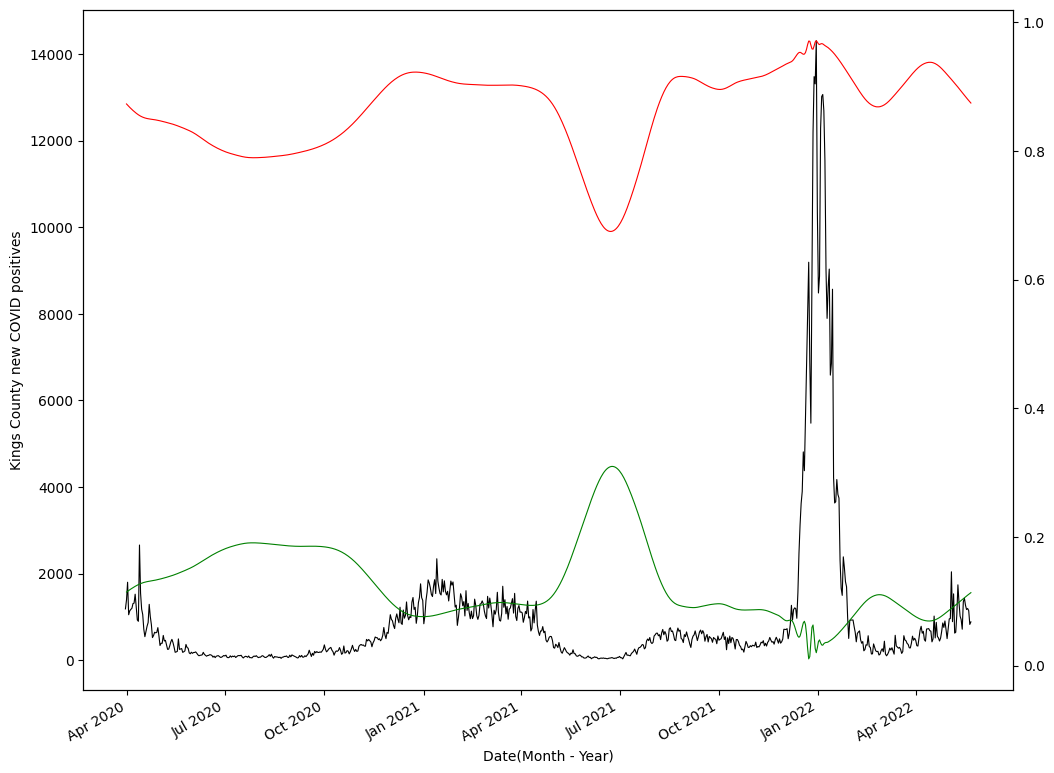

In [9]:
import datetime as dt
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

coefs = g_tv.get_coefs()

start_date = dt.date(2020, 3, 31)
end_date = dt.date(2022, 5, 22)

dates = [
    start_date + dt.timedelta(days=i)
    for i in range((end_date - start_date).days + 1)
]

fig, ax1 = plt.subplots(figsize=(12, 10))

# plot the kings county time series
ax1.plot(dates, vts[:, 23], color="black", linewidth=0.8)
ax1.set_ylabel("Kings County new COVID positives")
ax1.set_xlabel("Date(Month - Year)")

# Plot the coefficients.
ax2 = ax1.twinx()
ax2.plot(dates[1:], coefs[:, 0], color="red", linewidth=0.8)
ax2.plot(dates[1:], coefs[:, 1], color="green", linewidth=0.8)

#Date
ax1.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
fig.autofmt_xdate()

plt.show()

## Forecasting

In [10]:
def test_forecast(family,basis_orders,thresh,taus,refit,refit_endpoint_only,s=1,basis_order_min=None):
    """
    Runs the test of forecasting performance on the NY COVID data for TV-GNAR and global TV-AR
    Args:
        See document on TVGNAR class.
        basis_orders: list of basis order to search
        taus: list of tau to search
        s: max stage of neighbourhood
    Returns: 
        A NumPy array of forecasting errors.
        The first dim corresponds to different hyperparameter combinations (ps, basis_orders and taus)
        and the second dim corresponds to forecasting time.
    """
    sse_tvs_array = []
    for basis_order in basis_orders:
        for tau in taus:
            for p in range(1,11):
                sse_tvs = []
                for t in tqdm(range(580,650)):
                    g_tv = TVGNAR(p,[s for _ in range(p)],basis_order_min=basis_order_min,intercept=True ,global_intercept=False, tv_intercept=False,family=family,gpu=True,basis_order=basis_order,boundary_mode="reflect")
                    g_tv.fit(network_NY,vts_log[:t],thresh=thresh,tau=tau,refit=refit,refit_endpoint_only=refit_endpoint_only)
                    sse_tv = np.sum((vts_log[t] - g_tv.predict(1))**2)
                    sse_tvs.append(sse_tv)
                    del g_tv
                    gc.collect()
                    torch.cuda.empty_cache()
                print(basis_order,tau,p,np.mean(sse_tvs))
                sse_tvs_array.append(sse_tvs)
    return np.array(sse_tvs_array)

def test_forecast_vl(alphas):
    """
    Runs the test of forecasting performance on the NY COVID data for VAR and VARLasso
    Args:
        alphas: list of VARLasso penalisation parameters to search
    Returns: 
        A NumPy array of forecasting errors.
        The first dim corresponds to different hyperparameter combinations (alphas and ps)
        and the second dim corresponds to forecasting time.
    """
    sse_tvs_array = []
    for alpha in alphas:
        prange = range(1,11)
        for p in prange:
            sse_tvs = []
            for t in tqdm(range(580,650)):
                vl = VARLasso(p=p,alpha=alpha,fit_intercept=True,gpu=True)
                vl.fit(vts_log[:t])
                sse_tv = np.sum((vts_log[t] - vl.predict(vts_log[t-p:t]))**2)
                sse_tvs.append(sse_tv)
            print(alpha,p,np.mean(sse_tvs))
            sse_tvs_array.append(sse_tvs)
    return np.array(sse_tvs_array)

def test_forecast_stat(s,global_alpha=True):
    """
    Runs the test of forecasting performance on the NY COVID data for GNAR, NAR, AR and global-AR
    Args:
        s: int, max stage of neighbourhood
        global_alpha: bool, set whether the model is global
    Returns: 
        A NumPy array of forecasting errors.
        The first dim corresponds to different hyperparameter combinations (ps)
        and the second dim corresponds to forecasting time.
    """
    sse_tvs_array = []
    for p in range(1,11):
        sse_tvs = []
        for t in tqdm(range(580,650)):
            g = GNAR(p,[s for _ in range(p)],intercept=True ,global_intercept=False,global_alpha=global_alpha)
            g.fit(network_NY,vts_log[:t])
            sse_tv = np.sum((vts_log[t] - g.predict(1))**2)
            sse_tvs.append(sse_tv)
        print(p,np.mean(sse_tvs))
        sse_tvs_array.append(sse_tvs)
    return np.array(sse_tvs_array)

### TV-GNAR with DB4, hardthresholding and refitting, max stage of neighbourhood = 2

In [34]:
sse_tv_db4345_h_TT_2 = test_forecast("db4",[4,5],"hard",[1,1.5,2,2.5],True,True,2)

100%|██████████████████████████████████████████████████████████████████████████████████| 70/70 [00:21<00:00,  3.21it/s]


4 1 1 13.446922234167213


100%|██████████████████████████████████████████████████████████████████████████████████| 70/70 [00:30<00:00,  2.31it/s]


4 1 2 12.978054969758027


100%|██████████████████████████████████████████████████████████████████████████████████| 70/70 [00:36<00:00,  1.91it/s]


...

5 2.5 8 9.901064557707274


100%|██████████████████████████████████████████████████████████████████████████████████| 70/70 [03:08<00:00,  2.69s/it]


5 2.5 9 11.212759559520865


100%|██████████████████████████████████████████████████████████████████████████████████| 70/70 [03:34<00:00,  3.07s/it]

5 2.5 10 11.232767796311006


In [116]:
# prints the average one-step-ahead forecast errors over the two testing period 
# Day 591 to 620 and Day 621 to 650
sse_test = []
for t in range(10,40): # Day 591 to 620
    sse_val = np.mean(sse_tv_db4345_h_TT_2[:,:t],axis=1) # find the best hyperparameters using validation error from day 581 to day t-1
    sse_test.append(sse_tv_db4345_h_TT_2[:,t][np.argmin(sse_val)]) # Forecast error using that set of hyperparameters at day t
print(np.mean(sse_test))
sse_test = []
for t in range(40,70): # Day 621 to 650
    sse_val = np.mean(sse_tv_db4345_h_TT_2[:,t-10:t],axis=1) # find the best hyperparameters using validation error from day t-10 to day t-1
    sse_test.append(sse_tv_db4345_h_TT_2[:,t][np.argmin(sse_val)]) # Forecast error using that set of hyperparameters at day t
print(np.mean(sse_test))

7.802080762493335
12.074703155024034


### global TV-AR with DB4, hardthresholding and refitting

In [66]:
sse_tv_db4345_h_TT_0 = test_forecast("db4",[4,5],"hard",[1,1.5,2,2.5],True,True,0)

100%|██████████████████████████████████████████████████████████████████████████████████| 70/70 [00:19<00:00,  3.61it/s]


4 1 1 16.420348875057982


100%|██████████████████████████████████████████████████████████████████████████████████| 70/70 [00:23<00:00,  3.04it/s]


4 1 2 15.014300195541702


100%|██████████████████████████████████████████████████████████████████████████████████| 70/70 [00:29<00:00,  2.41it/s]


...

5 2.5 8 12.134318567174889


100%|██████████████████████████████████████████████████████████████████████████████████| 70/70 [00:55<00:00,  1.25it/s]


5 2.5 9 11.934413662976292


100%|██████████████████████████████████████████████████████████████████████████████████| 70/70 [01:01<00:00,  1.14it/s]

5 2.5 10 11.899503559775972


In [73]:
sse_test = [] #same as above
for t in range(10,40):
    sse_val = np.mean(sse_tv_db4345_h_TT_0[:,:t],axis=1)
    sse_test.append(sse_tv_db4345_h_TT_0[:,t][np.argmin(sse_val)])
print(np.mean(sse_test))
sse_test = []
for t in range(40,70):
    sse_val = np.mean(sse_tv_db4345_h_TT_0[:,t-10:t],axis=1)
    sse_test.append(sse_tv_db4345_h_TT_0[:,t][np.argmin(sse_val)])
print(np.mean(sse_test))

9.237590393412168
15.476509015363625


### VAR

In [28]:
sse_var = test_forecast_vl([0])

100%|█████████████████████████████████████████████████████████████████████████████████| 70/70 [00:00<00:00, 569.18it/s]


0 1 12.838364108591879


100%|█████████████████████████████████████████████████████████████████████████████████| 70/70 [00:00<00:00, 240.31it/s]


0 2 13.820578626392948


100%|█████████████████████████████████████████████████████████████████████████████████| 70/70 [00:00<00:00, 145.50it/s]


...

0 8 39.46888874093543


100%|██████████████████████████████████████████████████████████████████████████████████| 70/70 [00:03<00:00, 19.76it/s]


0 9 121.15911737925025


100%|██████████████████████████████████████████████████████████████████████████████████| 70/70 [00:03<00:00, 18.37it/s]

0 10 924.143921586145


In [31]:
sse_test = [] #same as above
for t in range(10,40):
    sse_val = np.mean(sse_var[:,:t],axis=1)
    sse_test.append(sse_var[:,t][np.argmin(sse_val)])
print(np.mean(sse_test))
sse_test = []
for t in range(40,70):
    sse_val = np.mean(sse_var[:,t-10:t],axis=1)
    sse_test.append(sse_var[:,t][np.argmin(sse_val)])
print(np.mean(sse_test))

10.02481115348241
16.616178630734883


### VARLasso

In [76]:
sse_vl = test_forecast_vl([0.006,0.008,0.01,0.012,0.014])

100%|██████████████████████████████████████████████████████████████████████████████████| 70/70 [00:15<00:00,  4.59it/s]


0.006 1 12.646979169619053


100%|██████████████████████████████████████████████████████████████████████████████████| 70/70 [00:23<00:00,  2.99it/s]


0.006 2 12.92648672830787


100%|██████████████████████████████████████████████████████████████████████████████████| 70/70 [00:32<00:00,  2.14it/s]


...

0.014 8 11.763341623637672


100%|██████████████████████████████████████████████████████████████████████████████████| 70/70 [01:00<00:00,  1.15it/s]


0.014 9 11.625084692402318


100%|██████████████████████████████████████████████████████████████████████████████████| 70/70 [01:04<00:00,  1.09it/s]

0.014 10 11.785806912561423


In [50]:
sse_test = [] #same as above
for t in range(10,40):
    sse_val = np.mean(sse_vl[:,:t],axis=1)
    sse_test.append(sse_vl[:,t][np.argmin(sse_val)])
print(np.mean(sse_test))
sse_test = []
for t in range(40,70):
    sse_val = np.mean(sse_vl[:,t-10:t],axis=1)
    sse_test.append(sse_vl[:,t][np.argmin(sse_val)])
print(np.mean(sse_test))

9.080671284790478
16.24274494267718


### NAR

In [4]:
sse_g_1 = test_forecast_stat(1) #max stage of neighbourhood is 1 for NAR

100%|██████████████████████████████████████████████████████████████████████████████████| 70/70 [00:03<00:00, 17.90it/s]


1 14.068415613173807


100%|██████████████████████████████████████████████████████████████████████████████████| 70/70 [00:03<00:00, 17.75it/s]


2 14.484710069906022


100%|██████████████████████████████████████████████████████████████████████████████████| 70/70 [00:04<00:00, 15.95it/s]


...

8 11.287473743672281


100%|██████████████████████████████████████████████████████████████████████████████████| 70/70 [00:06<00:00, 10.92it/s]


9 10.88171398157693


100%|██████████████████████████████████████████████████████████████████████████████████| 70/70 [00:06<00:00, 10.42it/s]

10 11.030419278417433


In [22]:
sse_test = [] #same as above
for t in range(10,40):
    sse_val = np.mean(sse_g_1[:,:t],axis=1)
    sse_test.append(sse_g_1[:,t][np.argmin(sse_val)])
print(np.mean(sse_test))
sse_test = []
for t in range(40,70):
    sse_val = np.mean(sse_g_1[:,30:t],axis=1)
    sse_test.append(sse_g_1[:,t][np.argmin(sse_val)])
print(np.mean(sse_test))

8.561710638256342
15.198348278207668


### GNAR

In [7]:
sse_g = test_forecast_stat(2)

100%|██████████████████████████████████████████████████████████████████████████████████| 70/70 [00:04<00:00, 17.14it/s]


1 13.728911604946422


100%|██████████████████████████████████████████████████████████████████████████████████| 70/70 [00:04<00:00, 15.82it/s]


2 13.854461125090529


100%|██████████████████████████████████████████████████████████████████████████████████| 70/70 [00:04<00:00, 14.50it/s]


...

8 10.604890715495893


100%|██████████████████████████████████████████████████████████████████████████████████| 70/70 [00:07<00:00,  9.13it/s]


9 10.33158355339428


100%|██████████████████████████████████████████████████████████████████████████████████| 70/70 [00:08<00:00,  8.64it/s]

10 10.738280392473637


In [87]:
sse_test = [] #same as above
for t in range(10,40):
    sse_val = np.mean(sse_g[:,:t],axis=1)
    sse_test.append(sse_g[:,t][np.argmin(sse_val)])
print(np.mean(sse_test))
sse_test = []
for t in range(40,70):
    sse_val = np.mean(sse_g[:,t-10:t],axis=1)
    sse_test.append(sse_g[:,t][np.argmin(sse_val)])
print(np.mean(sse_test))

8.354334490388537
14.690066007840887


### Global AR

In [8]:
sse_g_0 = test_forecast_stat(0)

100%|██████████████████████████████████████████████████████████████████████████████████| 70/70 [00:03<00:00, 18.16it/s]


1 17.01809007849907


100%|██████████████████████████████████████████████████████████████████████████████████| 70/70 [00:04<00:00, 17.17it/s]


2 16.095060648849


100%|██████████████████████████████████████████████████████████████████████████████████| 70/70 [00:03<00:00, 17.70it/s]


...

8 13.352067094339443


100%|██████████████████████████████████████████████████████████████████████████████████| 70/70 [00:04<00:00, 14.20it/s]


9 13.132733294754967


100%|██████████████████████████████████████████████████████████████████████████████████| 70/70 [00:04<00:00, 14.37it/s]

10 12.903762361134557


In [16]:
sse_test = [] #same as above
for t in range(10,40):
    sse_val = np.mean(sse_g_0[:,:t],axis=1)
    sse_test.append(sse_g_0[:,t][np.argmin(sse_val)])
print(np.mean(sse_test))
sse_test = []
for t in range(40,70):
    sse_val = np.mean(sse_g_0[:,:t],axis=1)
    sse_test.append(sse_g_0[:,t][np.argmin(sse_val)])
print(np.mean(sse_test))

9.260499905142389
18.441950747115424


### AR

In [24]:
sse_ar = test_forecast_stat(0,False)

100%|██████████████████████████████████████████████████████████████████████████████████| 70/70 [00:02<00:00, 31.87it/s]


1 17.33042153368937


100%|██████████████████████████████████████████████████████████████████████████████████| 70/70 [00:02<00:00, 23.89it/s]


2 16.201711246493034


100%|██████████████████████████████████████████████████████████████████████████████████| 70/70 [00:03<00:00, 20.04it/s]


...

8 13.282144666337834


100%|██████████████████████████████████████████████████████████████████████████████████| 70/70 [00:06<00:00, 10.72it/s]


9 13.048970363363292


100%|██████████████████████████████████████████████████████████████████████████████████| 70/70 [00:06<00:00, 10.32it/s]

10 12.847524788903096


In [25]:
sse_test = [] #same as above
for t in range(10,40):
    sse_val = np.mean(sse_ar[:,:t],axis=1)
    sse_test.append(sse_ar[:,t][np.argmin(sse_val)])
print(np.mean(sse_test))
sse_test = []
for t in range(40,70):
    sse_val = np.mean(sse_ar[:,t-10:t],axis=1)
    sse_test.append(sse_ar[:,t][np.argmin(sse_val)])
print(np.mean(sse_test))

9.227320206089068
20.879350887522428


## Plot of testing periods with raw time series

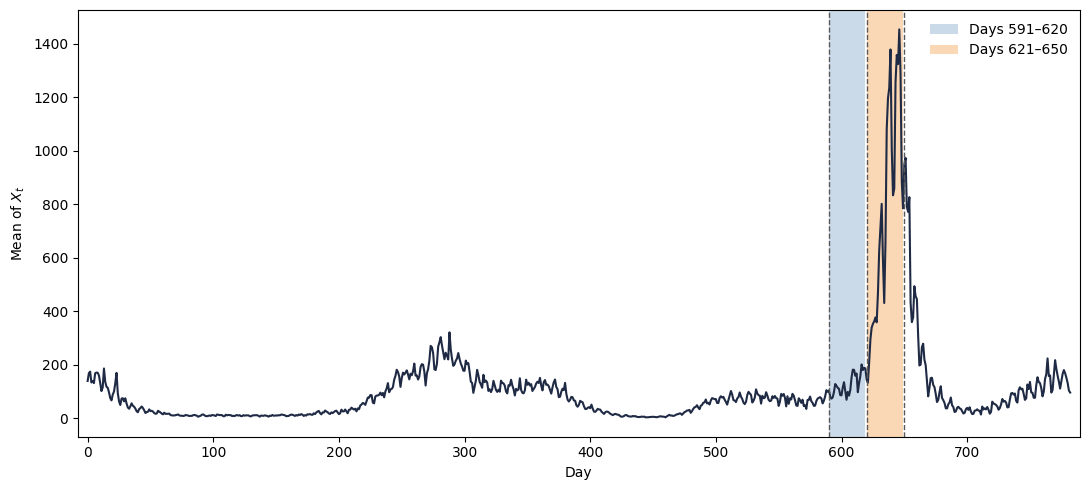

In [70]:
y = np.mean(vts, axis=1)
x = np.arange(len(vts))

fig, ax = plt.subplots(figsize=(11, 5))

ax.plot(x, y, lw=1.5, color='#1F2A44')

# testing periods
ax.axvspan(590, 619, alpha=0.32, facecolor='#5B8DB8', label='Days 591–620')
ax.axvspan(620, 649, alpha=0.35, facecolor='#F28E2B', label='Days 621–650')

# boundaries
ax.axvline(590, ls='--', lw=1, color='0.35')
ax.axvline(620, ls='--', lw=1, color='0.35')
ax.axvline(650, ls='--', lw=1, color='0.35')

ax.set_xlabel('Day')
ax.set_ylabel('Mean of $X_t$')
ax.legend(frameon=False)
ax.margins(x=0.01)

plt.tight_layout()
plt.show()

# Application on NHS Ventilation Bed data

In [12]:
def test_forecast2(family,basis_orders,thresh,taus,refit,refit_endpoint_only,s=1,basis_order_min=None,T1=260,T2=290):
    """
    Runs the test of forecasting performance on the NHS Ventilation Bed data for TV-GNAR and global TV-AR
    Args:
        See document on TVGNAR class.
        basis_orders: list of basis order to search
        taus: list of tau to search
        s: max stage of neighbourhood
        T1, T2: int, start and end of the forecasting period
    Returns: 
        A NumPy array of forecasting errors.
        The first dim corresponds to different hyperparameter combinations (basis_orders and taus)
        and the second dim corresponds to forecasting time.
    """
    sse_tvs_array = []
    for basis_order in basis_orders:
        for tau in taus:
            for p in range(1,2):
                sse_tvs = []
                for t in tqdm(range(T1,T2)):
                    g_tv = TVGNAR(p,[s for _ in range(p)],basis_order_min=basis_order_min,intercept=True ,global_intercept=False, tv_intercept=False,family=family,gpu=True,basis_order=basis_order,boundary_mode="reflect")
                    g_tv.fit(covid_network,covid_vts_log[:t],thresh=thresh,tau=tau,refit=refit,refit_endpoint_only=refit_endpoint_only)
                    sse_tv = np.sum((covid_vts_log[t] - g_tv.predict(1))**2)
                    sse_tvs.append(sse_tv)
                    del g_tv
                    gc.collect()
                    torch.cuda.empty_cache()
                print(basis_order,tau,p,np.mean(sse_tvs))
                sse_tvs_array.append(sse_tvs)
    return np.array(sse_tvs_array)

def test_forecast_stat2(s,global_alpha=True,network=covid_network,T1=260,T2=290):
    """
    Runs the test of forecasting performance on the NHS Ventilation Bed data for GNAR, NAR, AR, and global AR
    Args:
        s: int, max stage of neighbourhood
        global_alpha: bool, set whether the model is global
        network: Network class object, used for fitting GNAR
        T1, T2: int, start and end of the forecasting period
    Returns: 
        A NumPy array of forecasting errors.
        The first dim corresponds to p=1
        and the second dim corresponds to forecasting time.
    """
    sse_tvs_array = []
    for p in range(1,2):
        sse_tvs = []
        for t in tqdm(range(T1,T2)):
            g = GNAR(p,[s for _ in range(p)],intercept=True ,global_intercept=False,global_alpha=global_alpha)
            g.fit(covid_network,covid_vts_log[:t])
            sse_tv = np.sum((covid_vts_log[t] - g.predict(1))**2)
            sse_tvs.append(sse_tv)
        #print(p,np.mean(sse_tvs))
        sse_tvs_array.append(sse_tvs)
    return np.array(sse_tvs_array)

def test_forecast_vl2(alphas,T1=260,T2=290):
    """
    Runs the test of forecasting performance on the NHS Ventilation Bed data for VAR and VARLasso
    Args:
        alphas: list of VARLasso penalisation parameters to search
        T1, T2: int, start and end of the forecasting period
    Returns: 
        A NumPy array of forecasting errors.
        The first dim corresponds to different hyperparameter combinations (alphas)
        and the second dim corresponds to forecasting time.
    """
    sse_tvs_array = []
    for alpha in alphas:
        p=1
        sse_tvs = []
        for t in tqdm(range(T1,T2)):
            vl = VARLasso(p=p,alpha=alpha,fit_intercept=True,gpu=True)
            vl.fit(covid_vts_log[:t])
            sse_tv = np.sum((covid_vts_log[t] - vl.predict(covid_vts_log[t-p:t]))**2)
            sse_tvs.append(sse_tv)
        print(alpha,p,np.mean(sse_tvs))
        sse_tvs_array.append(sse_tvs)
    return np.array(sse_tvs_array)


### TV-GNAR with DB4, hardthresholding and refitting

In [1249]:
nhs_sse_tv_db4345_h_TT_1 = test_forecast2("db4",[4,5],"hard",[0.25,0.5,.75,1],True,True,1)

100%|██████████████████████████████████████████████████████████████████████████████████| 30/30 [00:15<00:00,  1.89it/s]


4 0.25 1 9.877687672894243


100%|██████████████████████████████████████████████████████████████████████████████████| 30/30 [00:15<00:00,  1.91it/s]


4 0.5 1 9.878510228461888


100%|██████████████████████████████████████████████████████████████████████████████████| 30/30 [00:15<00:00,  1.88it/s]


...

5 0.5 1 9.477036291849439


100%|██████████████████████████████████████████████████████████████████████████████████| 30/30 [00:17<00:00,  1.69it/s]


5 0.75 1 9.475375156547068


100%|██████████████████████████████████████████████████████████████████████████████████| 30/30 [00:18<00:00,  1.66it/s]

5 1 1 9.485075040160146


In [1250]:
# prints the average one-step-ahead forecast errors over the testing period Day 271 to 290
T=10
sse_test = []
for t in range(T,T+20): # Day 271 to 290
    sse_val = np.mean(nhs_sse_tv_db4345_h_TT_1[:,:t],axis=1) # find the best hyperparameters using validation error from day 261 to day t-1
    sse_test.append(nhs_sse_tv_db4345_h_TT_1[:,t][np.argmin(sse_val)]) # Forecast error using that set of hyperparameters at day t
print(T,np.mean(sse_test))

10 9.41205353417033


In [1245]:
nhs_sse_tv_db4345_h_TT_1_end = test_forecast2("db4",[4,5],"hard",[.1,.15,.2,0.25],True,True,1,T1=432,T2=452)

100%|██████████████████████████████████████████████████████████████████████████████████| 20/20 [00:13<00:00,  1.51it/s]


4 0.1 1 6.935594990805045


100%|██████████████████████████████████████████████████████████████████████████████████| 20/20 [00:13<00:00,  1.46it/s]


4 0.15 1 6.935608045866312


100%|██████████████████████████████████████████████████████████████████████████████████| 20/20 [00:13<00:00,  1.52it/s]


...

5 0.15 1 7.079333833903244


100%|██████████████████████████████████████████████████████████████████████████████████| 20/20 [00:14<00:00,  1.42it/s]


5 0.2 1 7.079188374848963


100%|██████████████████████████████████████████████████████████████████████████████████| 20/20 [00:14<00:00,  1.41it/s]

5 0.25 1 7.07874572109605


In [1246]:
# prints the average one-step-ahead forecast errors over the testing period Day 443 to 452
T=10
sse_test = []
for t in range(T,T+10): # Day 443 to 452
    sse_val = np.mean(nhs_sse_tv_db4345_h_TT_1_end[:,:t],axis=1) # find the best hyperparameters using validation error from day 433 to day t-1
    sse_test.append(nhs_sse_tv_db4345_h_TT_1_end[:,t][np.argmin(sse_val)]) # Forecast error using that set of hyperparameters at day t
print(T,np.mean(sse_test)) 

10 7.221771372090053


### Global TV-AR with DB4, hardthresholding and refitting

In [1251]:
nhs_sse_tv_db4345_h_TT_0 = test_forecast2("db4",[4,5],"hard",[0.25,0.5,.75,1],True,True,0)

100%|██████████████████████████████████████████████████████████████████████████████████| 30/30 [00:17<00:00,  1.73it/s]


4 0.25 1 9.948735562039353


100%|██████████████████████████████████████████████████████████████████████████████████| 30/30 [00:16<00:00,  1.82it/s]


4 0.5 1 9.95451345906682


100%|██████████████████████████████████████████████████████████████████████████████████| 30/30 [00:16<00:00,  1.77it/s]


...

5 0.5 1 9.883002869791419


100%|██████████████████████████████████████████████████████████████████████████████████| 30/30 [00:15<00:00,  1.92it/s]


5 0.75 1 9.88742175680419


100%|██████████████████████████████████████████████████████████████████████████████████| 30/30 [00:15<00:00,  1.88it/s]

5 1 1 9.921682070636928


In [1252]:
#same as above
T=10
sse_test = []
for t in range(T,T+20):
    sse_val = np.mean(nhs_sse_tv_db4345_h_TT_0[:,:t],axis=1)
    sse_test.append(nhs_sse_tv_db4345_h_TT_0[:,t][np.argmin(sse_val)])
print(T,np.mean(sse_test))

10 9.828649471759451


In [1247]:
nhs_sse_tv_db4345_h_TT_0_end = test_forecast2("db4",[4,5],"hard",[0.25,0.5,.75,1],True,True,0,T1=432,T2=452)

100%|██████████████████████████████████████████████████████████████████████████████████| 20/20 [00:12<00:00,  1.66it/s]


4 0.25 1 6.966068960302593


100%|██████████████████████████████████████████████████████████████████████████████████| 20/20 [00:12<00:00,  1.60it/s]


4 0.5 1 6.968833151499522


100%|██████████████████████████████████████████████████████████████████████████████████| 20/20 [00:11<00:00,  1.69it/s]


...

5 0.5 1 7.039583335587222


100%|██████████████████████████████████████████████████████████████████████████████████| 20/20 [00:12<00:00,  1.58it/s]


5 0.75 1 7.028389611236484


100%|██████████████████████████████████████████████████████████████████████████████████| 20/20 [00:12<00:00,  1.59it/s]

5 1 1 6.978076811310855


In [1248]:
#same as above
T=10
sse_test = []
for t in range(T,T+10):
    sse_val = np.mean(nhs_sse_tv_db4345_h_TT_0_end[:,:t],axis=1)
    sse_test.append(nhs_sse_tv_db4345_h_TT_0_end[:,t][np.argmin(sse_val)])
print(T,np.mean(sse_test))

10 7.24426448170634


### GNAR

In [1159]:
nhs_sse_g = test_forecast_stat2(1)
#same as above
T=10
sse_test = []
for t in range(T,T+20):
    sse_val = np.mean(nhs_sse_g[:,:t],axis=1)
    sse_test.append(nhs_sse_g[:,t][np.argmin(sse_val)])
print(T,np.mean(sse_test))

100%|██████████████████████████████████████████████████████████████████████████████████| 30/30 [00:06<00:00,  4.86it/s]

10 9.836964713137595


In [1232]:
nhs_sse_g = test_forecast_stat2(1,T1=432,T2=452)
#same as above
T=10
sse_test = []
for t in range(T,T+10):
    sse_val = np.mean(nhs_sse_g[:,:t],axis=1)
    sse_test.append(nhs_sse_g[:,t][np.argmin(sse_val)])
print(T,np.mean(sse_test))

100%|██████████████████████████████████████████████████████████████████████████████████| 20/20 [00:08<00:00,  2.37it/s]

10 7.2530302966827715


### global AR

In [1160]:
nhs_sse_g = test_forecast_stat2(0)
#same as above
T=10
sse_test = []
for t in range(T,T+20):
    sse_val = np.mean(nhs_sse_g[:,:t],axis=1)
    sse_test.append(nhs_sse_g[:,t][np.argmin(sse_val)])
print(T,np.mean(sse_test))

100%|██████████████████████████████████████████████████████████████████████████████████| 30/30 [00:06<00:00,  4.39it/s]

10 10.591342290705324


In [1233]:
nhs_sse_g = test_forecast_stat2(0,T1=432,T2=452)
#same as above
T=10
sse_test = []
for t in range(T,T+10):
    sse_val = np.mean(nhs_sse_g[:,:t],axis=1)
    sse_test.append(nhs_sse_g[:,t][np.argmin(sse_val)])
print(T,np.mean(sse_test))

100%|██████████████████████████████████████████████████████████████████████████████████| 20/20 [00:08<00:00,  2.28it/s]

10 7.3919630258037525


### AR

In [1195]:
nhs_sse_g = test_forecast_stat2(0,False)
#same as above
T=10
sse_test = []
for t in range(T,T+20):
    sse_val = np.mean(nhs_sse_g[:,:t],axis=1)
    sse_test.append(nhs_sse_g[:,t][np.argmin(sse_val)])
print(T,np.mean(sse_test))

100%|██████████████████████████████████████████████████████████████████████████████████| 30/30 [00:01<00:00, 21.40it/s]

10 10.593779322987237


In [1241]:
nhs_sse_g = test_forecast_stat2(0,False,T1=432,T2=452)
#same as above
T=10
sse_test = []
for t in range(T,T+10):
    sse_val = np.mean(nhs_sse_g[:,:t],axis=1)
    sse_test.append(nhs_sse_g[:,t][np.argmin(sse_val)])
print(T,np.mean(sse_test))

100%|██████████████████████████████████████████████████████████████████████████████████| 20/20 [00:01<00:00, 12.99it/s]

10 7.430800943102961


### VARLasso

In [1220]:
nhs_sse_vl = test_forecast_vl2([0.008,0.009,0.01,0.011,0.012])

100%|██████████████████████████████████████████████████████████████████████████████████| 30/30 [00:07<00:00,  3.81it/s]


0.008 1 9.628401550076127


100%|██████████████████████████████████████████████████████████████████████████████████| 30/30 [00:07<00:00,  4.09it/s]


0.009 1 9.624892702640834


100%|██████████████████████████████████████████████████████████████████████████████████| 30/30 [00:07<00:00,  4.14it/s]


0.01 1 9.642632382880615


100%|██████████████████████████████████████████████████████████████████████████████████| 30/30 [00:07<00:00,  4.23it/s]


0.011 1 9.660996207464216


100%|██████████████████████████████████████████████████████████████████████████████████| 30/30 [00:06<00:00,  4.69it/s]

0.012 1 9.68367390604812


In [1226]:
#same as above
T=10
sse_test = []
for t in range(T,T+20):
    sse_val = np.mean(nhs_sse_vl[:,:t],axis=1)
    sse_test.append(nhs_sse_vl[:,t][np.argmin(sse_val)])
print(T,np.mean(sse_test))

10 9.826212090276027


In [1228]:
nhs_sse_vl_end = test_forecast_vl2([0.008,0.009,0.01,0.011,0.012],432,452)

100%|██████████████████████████████████████████████████████████████████████████████████| 20/20 [00:06<00:00,  3.19it/s]


0.008 1 7.974078768158274


100%|██████████████████████████████████████████████████████████████████████████████████| 20/20 [00:05<00:00,  3.55it/s]


0.009 1 7.955490365292457


100%|██████████████████████████████████████████████████████████████████████████████████| 20/20 [00:05<00:00,  3.49it/s]


0.01 1 7.948996608538502


100%|██████████████████████████████████████████████████████████████████████████████████| 20/20 [00:05<00:00,  3.94it/s]


0.011 1 7.9522140404274335


100%|██████████████████████████████████████████████████████████████████████████████████| 20/20 [00:05<00:00,  3.91it/s]

0.012 1 7.95584051066147


In [1229]:
#same as above
T=10
sse_test = []
for t in range(T,T+10):
    sse_val = np.mean(nhs_sse_vl_end[:,:t],axis=1)
    sse_test.append(nhs_sse_vl_end[:,t][np.argmin(sse_val)])
print(T,np.mean(sse_test))

10 8.25336799657262


### VAR

In [1222]:
nhs_sse_var = test_forecast_vl2([0])

100%|█████████████████████████████████████████████████████████████████████████████████| 30/30 [00:00<00:00, 247.73it/s]

0 1 21.00740990124475


In [1224]:
#same as above
T=10
sse_test = []
for t in range(T,T+20):
    sse_val = np.mean(nhs_sse_var[:,:t],axis=1)
    sse_test.append(nhs_sse_var[:,t][np.argmin(sse_val)])
print(T,np.mean(sse_test))

10 20.081885819853966


In [1230]:
nhs_sse_var_end = test_forecast_vl2([0],432,452)

100%|█████████████████████████████████████████████████████████████████████████████████| 20/20 [00:00<00:00, 147.09it/s]

0 1 11.580393252649841


In [1231]:
#same as above
T=10
sse_test = []
for t in range(T,T+10):
    sse_val = np.mean(nhs_sse_var_end[:,:t],axis=1)
    sse_test.append(nhs_sse_var_end[:,t][np.argmin(sse_val)])
print(T,np.mean(sse_test))

10 12.387907983554715


## Plot of testing periods with raw time series

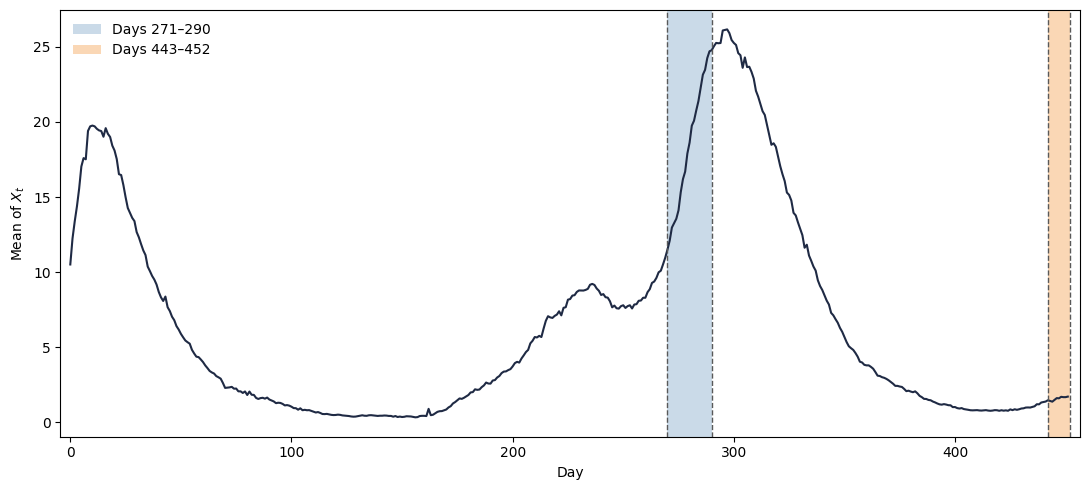

In [73]:
y = np.mean(covid_vts, axis=1)
x = np.arange(len(covid_vts))

fig, ax = plt.subplots(figsize=(11, 5))

ax.plot(x, y, lw=1.5, color='#1F2A44')

# testing periods
ax.axvspan(270, 290, alpha=0.32, facecolor='#5B8DB8', label='Days 271–290')
ax.axvspan(442, 452, alpha=0.35, facecolor='#F28E2B', label='Days 443–452')

# boundaries
ax.axvline(270, ls='--', lw=1, color='0.35')
ax.axvline(290, ls='--', lw=1, color='0.35')
ax.axvline(442, ls='--', lw=1, color='0.35')
ax.axvline(452, ls='--', lw=1, color='0.35')

ax.set_xlabel('Day')
ax.set_ylabel('Mean of $X_t$')
ax.legend(frameon=False)
ax.margins(x=0.01)

plt.tight_layout()
plt.show()

# Estimation Simulation in the appendix 

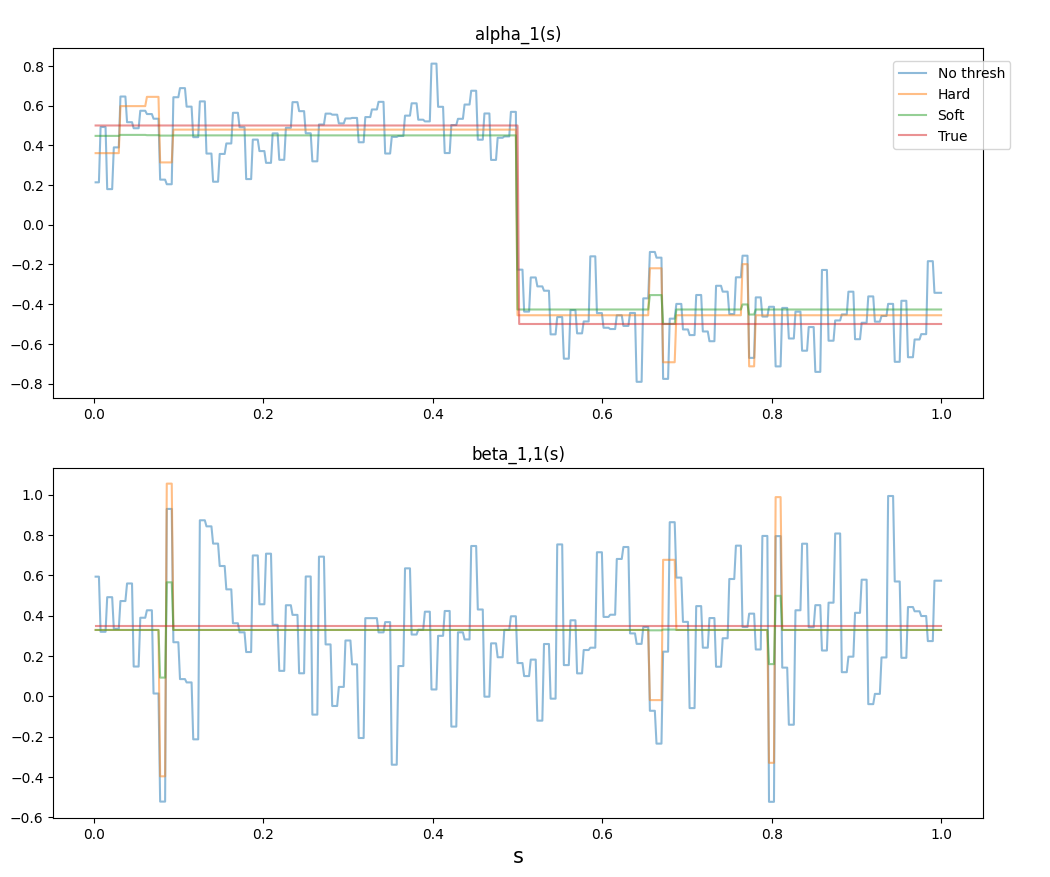

In [2]:
T = 512
b=T
random.seed(2)
network = random_network(10)

def alpha_fun(t):
    t = t/T
    return np.select([t<=0.5,t>0.5],[0.5,-0.5])

def beta_fun(t):
    return np.ones_like(t)*0.35

coefs = np.zeros((T+b+1,2))
coefs[:,0] = alpha_fun(np.arange(-b,T+1))
coefs[:,1] = beta_fun(np.arange(-b,T+1))

np.random.seed(1)
vts_sim = TVGNAR_sim(network, 1, [1], coefs, intercept=False, global_intercept=True, error_cov_mat=.1*np.identity(network.size),length=T+1,burn_in=b)

g_tv_h = TVGNAR(1,[1],intercept=False,family="haar")
g_tv_h.fit(network,vts_sim,thresh=None)

g_tv_h_h = TVGNAR(1,[1],intercept=False,family="haar")
g_tv_h_h.fit(network,vts_sim,thresh="hard",ind_thresh=False)
#print(g_tv_h_h.mad)

g_tv_h_s = TVGNAR(1,[1],intercept=False,family="haar")
g_tv_h_s.fit(network,vts_sim,thresh="soft",ind_thresh=False)

fig, axs = plt.subplots(2,figsize=(12,10))
#fig.suptitle('Estimation of alpha_1,beta_1,1 with haar wavelet and different thresholding')
for i in range(2):
    axs[i].plot(np.arange(1,T+1)/T,g_tv_h.get_coefs()[:,i],label="No thresh",alpha=0.5)
    axs[i].plot(np.arange(1,T+1)/T,g_tv_h_h.get_coefs()[:,i],label="Hard",alpha=0.5)
    axs[i].plot(np.arange(1,T+1)/T,g_tv_h_s.get_coefs()[:,i],label="Soft",alpha=0.5)
    axs[i].plot(np.arange(1,T+1)/T,coefs[b+1:,i],label="True",alpha=0.5)
handles, labels = axs[-1].get_legend_handles_labels()
axs[0].title.set_text('alpha_1(s)')
axs[1].title.set_text('beta_1,1(s)')
axs[1].set_xlabel("s",fontsize=15)
fig.legend(handles, labels, loc=(0.85,0.83))

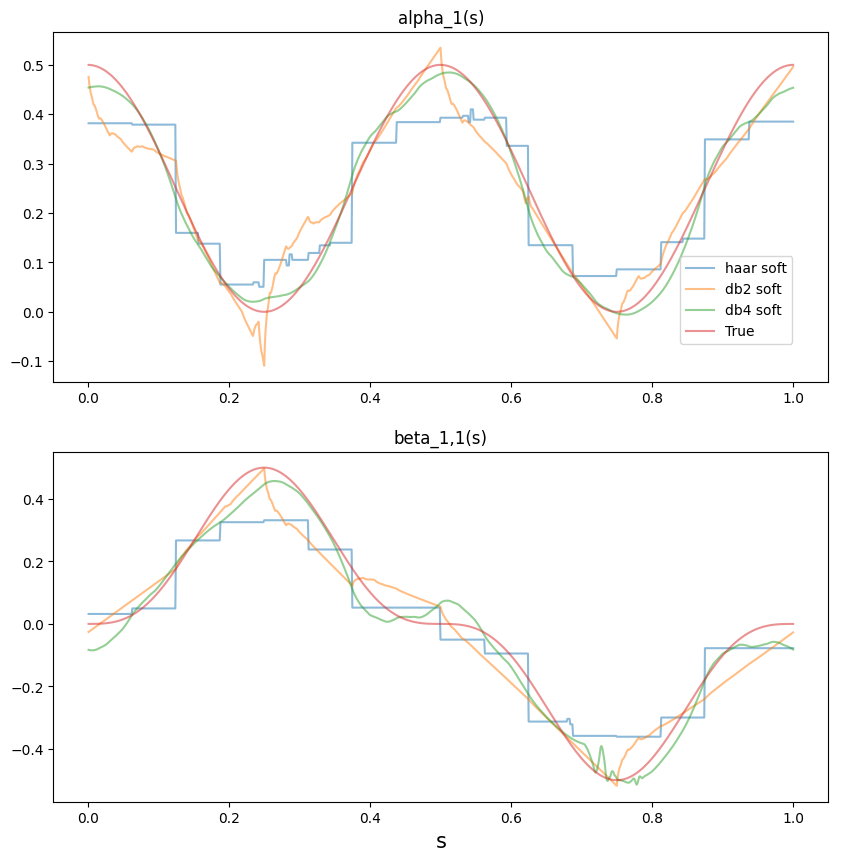

In [3]:
T = 1000
b=T
random.seed(1)
network = tridiagonal_network(32)

def alpha_fun(t):
    return np.cos(t/(T)*2*np.pi)**2/2

def beta_2_fun(t):
    return -np.tanh((t/(T)-0.5)*2*np.pi)**2/2+np.cos(t/(T)*4*np.pi-np.pi)/5+1/2

def beta_fun(t):
    return np.sin(t/(T)*2*np.pi)**(3)*0.5

def const_fun(t):
    return np.ones_like(t)

coefs = np.zeros((T+b+1,3))
coefs[:,0] = alpha_fun(np.arange(-b,T+1))
coefs[:,1] = beta_fun(np.arange(-b,T+1))
coefs[:,2] = const_fun(np.arange(-b,T+1))

np.random.seed(1)
vts_sim = TVGNAR_sim(network, 1, [1], coefs, intercept=True, global_intercept=True, error_cov_mat=0.1*np.identity(network.size),length=T+1,burn_in=b)
np.savetxt("vts_sim.txt",vts_sim)

g_tv_h_s = TVGNAR(1,[1],intercept=True,global_intercept=True,family="haar")
g_tv_h_s.fit(network,vts_sim,thresh="soft",ind_thresh=False,mad_level=1)

g_tv = GNAR(1,[1],intercept=True)
g_tv.fit(network,vts_sim)

g_tv_db2_s = TVGNAR(1,[1],intercept=True,global_intercept=True,family="db2",basis_order_min=2)
g_tv_db2_s.fit(network,vts_sim,thresh="soft",ind_thresh=False,mad_level=1)

g_tv_db4_s = TVGNAR(1,[1],intercept=True,global_intercept=True,family="db4",basis_order_min=3)
g_tv_db4_s.fit(network,vts_sim,thresh="soft",ind_thresh=False,mad_level=1)


fig, axs = plt.subplots(2,figsize=(10,10))
#fig.suptitle('alpha_t,beta_t,drift_t with db4 and different thresholding')
for i in range(2):
    axs[i].plot(np.arange(1,T+1)/T,g_tv_h_s.get_coefs()[:,i],label="haar soft",alpha=0.5)
    axs[i].plot(np.arange(1,T+1)/T,g_tv_db2_s.get_coefs()[:,i],label="db2 soft",alpha=0.5)
    axs[i].plot(np.arange(1,T+1)/T,g_tv_db4_s.get_coefs()[:,i],label="db4 soft",alpha=0.5)
    axs[i].plot(np.arange(1,T+1)/T,coefs[b+1:,i],label="True",alpha=0.5)
axs[0].title.set_text('alpha_1(s)')
axs[1].title.set_text('beta_1,1(s)')
axs[1].set_xlabel("s",fontsize=15)
handles, labels = axs[-1].get_legend_handles_labels()
fig.legend(handles, labels, loc=(0.8,0.6))

In [8]:
def simulation_1(N,T,rep=100,type="full"):
    b=T
    
    def alpha_fun(t):
        return np.cos(t/(T)*2*np.pi)**2/2

    def beta_fun(t):
        return np.sin(t/(T)*2*np.pi)**(3)*0.5
    
    coefs = np.zeros((T+b+1,2))
    coefs[:,0] = alpha_fun(np.arange(-b,T+1))
    coefs[:,1] = beta_fun(np.arange(-b,T+1))
    
    mses_s = []
    
    for seed in tqdm(range(rep)):
        random.seed(seed)
        if type == "tri":
            network = tridiagonal_network(N)
        elif type == "full":
            network = full_network(N)
        elif type == "ran":
            network = random_network_2(N,7)
        np.random.seed(seed)
        
        vts_sim = TVGNAR_sim(network, 1, [1], coefs, intercept=False, global_intercept=True, error_cov_mat=0.1*np.identity(network.size),length=T+1,burn_in=b)
        
        g_tv_h_s = TVGNAR(1,[1],intercept=False,family="db4")
        g_tv_h_s.fit(network,vts_sim,thresh="soft",ind_thresh=False,mad_level=1)
        mses_s.append( np.mean( (g_tv_h_s.get_coefs()-coefs[b+1:,:])**2 ,axis=0) )
    
    mses_s = np.array(mses_s)
    print(np.mean(mses_s,axis=0),np.std(mses_s,axis=0))

In [3]:
simulation_1(4,64,100, "full")
simulation_1(8,128,100, "full")
simulation_1(16,256,100, "full")
simulation_1(32,512,100, "full")

100%|████████████████████████████████████████████████████████████████████████████████| 100/100 [00:02<00:00, 41.56it/s]


[0.04558012 0.21358304] [0.02616182 0.16866208]


100%|████████████████████████████████████████████████████████████████████████████████| 100/100 [00:07<00:00, 14.09it/s]


[0.01002767 0.1457188 ] [0.00501188 0.10510868]


100%|████████████████████████████████████████████████████████████████████████████████| 100/100 [00:23<00:00,  4.28it/s]


[0.00278513 0.12666099] [0.00123029 0.17728177]


100%|████████████████████████████████████████████████████████████████████████████████| 100/100 [01:11<00:00,  1.40it/s]

[0.00088329 0.09286458] [0.00027309 0.08043052]


In [126]:
simulation_1(8,512,100 , "ran")
simulation_1(16,512,100, "ran")
simulation_1(32,512,100, "ran")
simulation_1(64,512,100, "ran")

100%|████████████████████████████████████████████████████████████████████████████████| 100/100 [00:19<00:00,  5.20it/s]


[0.00289049 0.02269363] [0.00118541 0.01121301]


100%|████████████████████████████████████████████████████████████████████████████████| 100/100 [00:21<00:00,  4.69it/s]


[0.0013705  0.00788463] [0.00050691 0.00351295]


100%|████████████████████████████████████████████████████████████████████████████████| 100/100 [00:34<00:00,  2.93it/s]


[0.00085977 0.00435932] [0.00026102 0.00134402]


100%|████████████████████████████████████████████████████████████████████████████████| 100/100 [06:43<00:00,  4.04s/it]

[0.00060385 0.00260671] [0.00012702 0.00063686]


In [45]:
simulation_1(8,512,100, "full")
simulation_1(16,512,100, "full")
simulation_1(32,512,100, "full")
simulation_1(64,512,100, "full")

100%|████████████████████████████████████████████████████████████████████████████████| 100/100 [00:30<00:00,  3.24it/s]


[0.00289049 0.02269362] [0.00118542 0.011213  ]


100%|████████████████████████████████████████████████████████████████████████████████| 100/100 [00:33<00:00,  3.01it/s]


[0.00139867 0.02664479] [0.00050909 0.01432206]


100%|████████████████████████████████████████████████████████████████████████████████| 100/100 [01:12<00:00,  1.38it/s]


[0.00088329 0.09286458] [0.00027309 0.08043052]


100%|████████████████████████████████████████████████████████████████████████████████| 100/100 [07:40<00:00,  4.60s/it]

[0.00061463 0.08666907] [0.00013239 0.08650418]


In [46]:
simulation_1(8,512,100, "tri")
simulation_1(16,512,100, "tri")
simulation_1(32,512,100, "tri")
simulation_1(64,512,100, "tri")

100%|████████████████████████████████████████████████████████████████████████████████| 100/100 [00:30<00:00,  3.26it/s]


[0.00287425 0.00499796] [0.00117446 0.0019337 ]


100%|████████████████████████████████████████████████████████████████████████████████| 100/100 [00:33<00:00,  3.03it/s]


[0.00140683 0.0030252 ] [0.00050237 0.00102183]


100%|████████████████████████████████████████████████████████████████████████████████| 100/100 [01:12<00:00,  1.38it/s]


[0.00089034 0.00203676] [0.0002742  0.00055745]


100%|████████████████████████████████████████████████████████████████████████████████| 100/100 [07:42<00:00,  4.63s/it]

[0.00060106 0.00138785] [0.00012874 0.00024931]


In [20]:
simulation_1(128,512,100, "full")
simulation_1(128,512,100, "tri")

100%|████████████████████████████████████████████████████████████████████████████████| 100/100 [28:41<00:00, 17.22s/it]


[9.74923454e-01 1.58322008e+04] [4.25917587e+00 6.86687151e+04]


100%|████████████████████████████████████████████████████████████████████████████████| 100/100 [28:36<00:00, 17.17s/it]

[0.00044581 0.0003654 ] [5.31993807e-05 1.19016377e-04]
